In [5]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

Cargar data

In [13]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)
print('------------------------------------------')
# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [14]:
X

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [12]:
y

,Diagnosis
0,M
1,M
2,M
3,M
4,M
...,...
564,M
565,M
566,M
567,M


# Análisis exploratorio de los datos

In [15]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

In [16]:
y.value_counts()

Diagnosis
B            357
M            212
Name: count, dtype: int64

In [17]:
X.corr()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
radius1,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture1,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter1,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area1,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness1,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness1,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity1,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave_points1,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry1,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension1,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


# Preprocesamiento de los datos

In [ ]:
#Escalar datos y mostrar primera fila
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
X_scaled[:1] # es como X_scaled[:1]

array([[ 1.09706398, -2.07333501,  1.26993369,  0.9843749 ,  1.56846633,
         3.28351467,  2.65287398,  2.53247522,  2.21751501,  2.25574689,
         2.48973393, -0.56526506,  2.83303087,  2.48757756, -0.21400165,
         1.31686157,  0.72402616,  0.66081994,  1.14875667,  0.90708308,
         1.88668963, -1.35929347,  2.30360062,  2.00123749,  1.30768627,
         2.61666502,  2.10952635,  2.29607613,  2.75062224,  1.93701461]])

In [19]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=2)
kmeans.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
X['Cluster'] = kmeans.labels_
X.head()

C:\Users\l\AppData\Local\Temp\ipykernel_10368\320688289.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = kmeans.labels_


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Cluster
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


# Reducción de dimensionalidad con PCA

In [21]:
# Reducción de dimensionalidad con PCA
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
pca_components_3d=pca.fit_transform(X_scaled)
pca_components_3d[:1]

array([[ 9.19283683,  1.94858307, -1.12316616]])

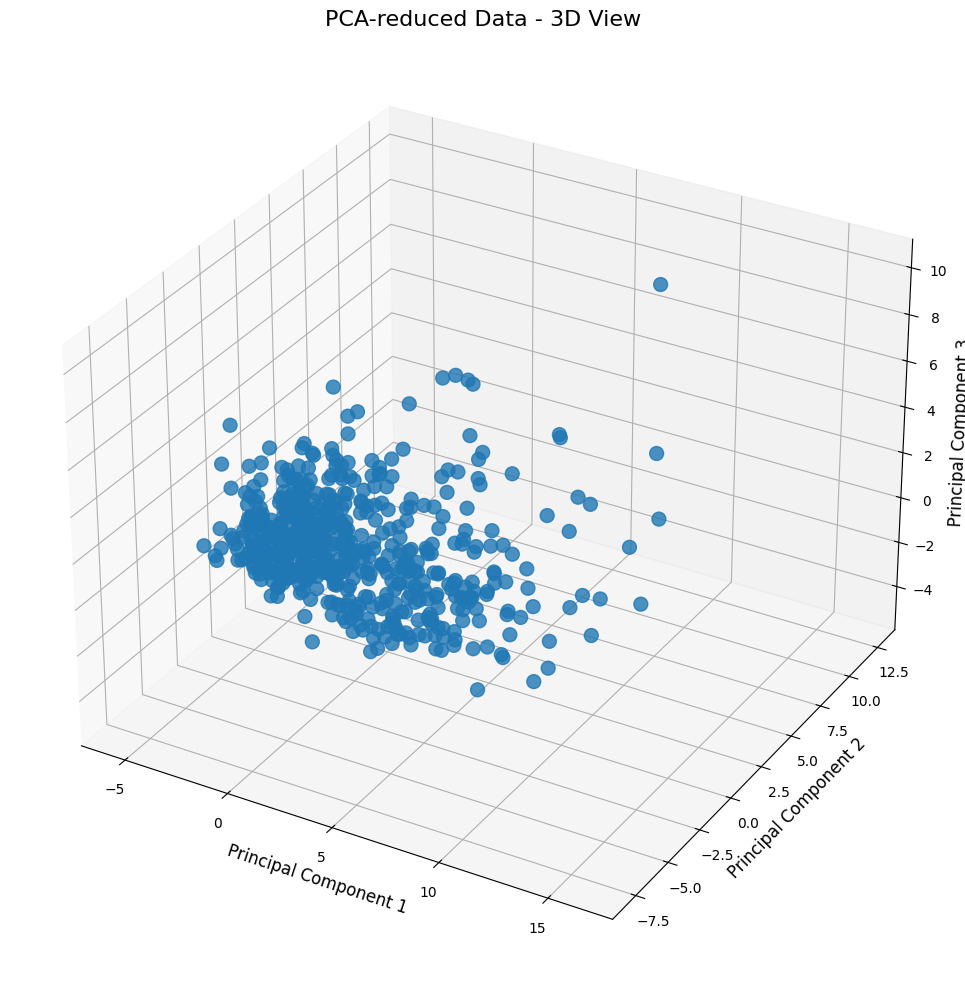

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

pca_df_3d = pd.DataFrame(data=pca_components_3d, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
        pca_df_3d['Principal Component 1'],
        pca_df_3d['Principal Component 2'],
        pca_df_3d['Principal Component 3'],
        s=100,
        alpha=0.8
    )
ax.set_title('PCA-reduced Data - 3D View', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
plt.tight_layout()
plt.show()

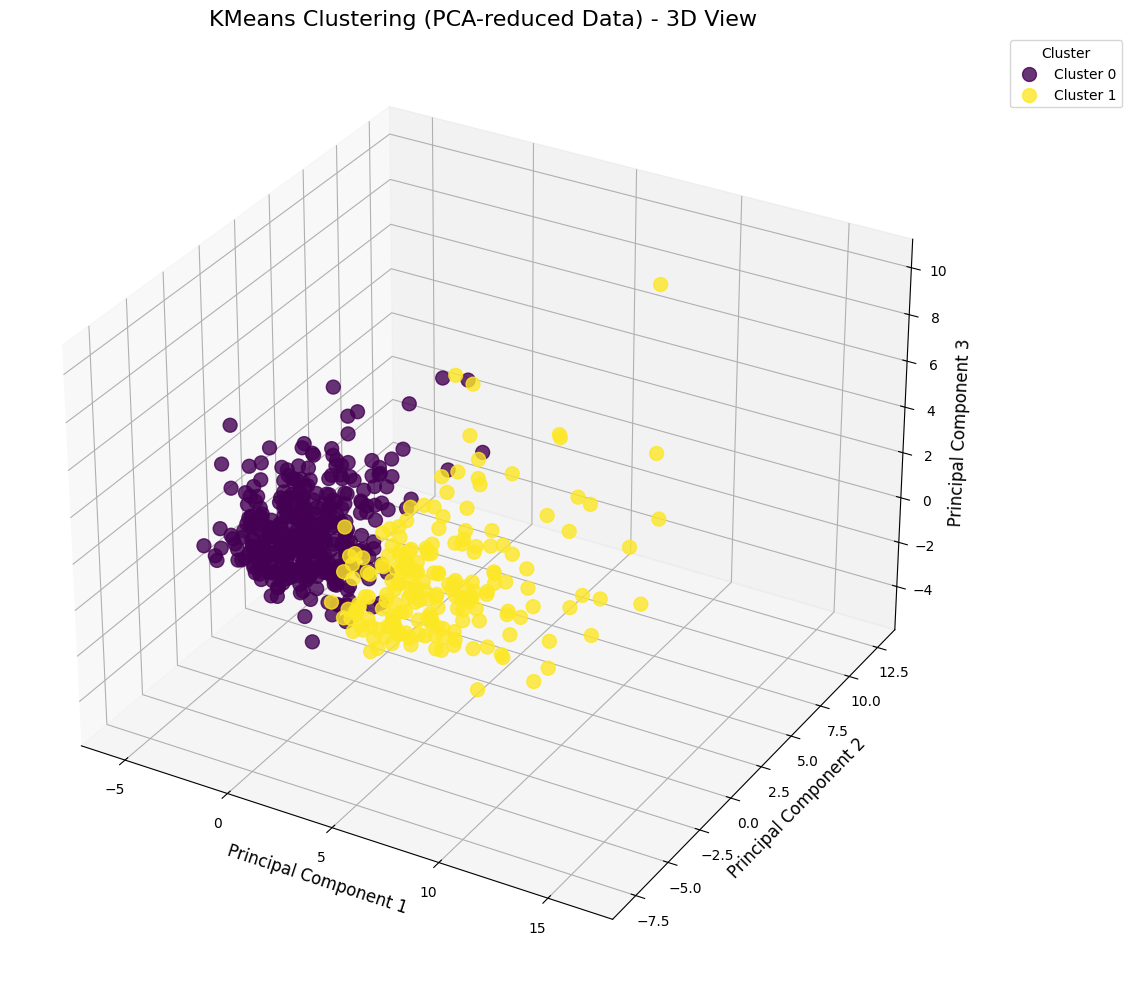

In [23]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

pca_df_3d = pd.DataFrame(data=pca_components_3d, columns=['Principal Component 1', 'Principal Component 2', 'Principal Component 3'])
pca_df_3d['Cluster'] = X['Cluster']

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Define a colormap for consistent coloring
cmap = plt.get_cmap('viridis', len(pca_df_3d['Cluster'].unique()))

for cluster in sorted(pca_df_3d['Cluster'].unique()):
    cluster_data = pca_df_3d[pca_df_3d['Cluster'] == cluster]
    ax.scatter(
        cluster_data['Principal Component 1'],
        cluster_data['Principal Component 2'],
        cluster_data['Principal Component 3'],
        label=f'Cluster {cluster}',
        color=cmap(cluster),
        s=100,
        alpha=0.8
    )

ax.set_title('KMeans Clustering (PCA-reduced Data) - 3D View', fontsize=16)
ax.set_xlabel('Principal Component 1', fontsize=12)
ax.set_ylabel('Principal Component 2', fontsize=12)
ax.set_zlabel('Principal Component 3', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
#analizar la varianza explicada por cada componente
pca.explained_variance_

array([13.30499079,  5.7013746 ,  2.82291016])

In [25]:
sum(pca.explained_variance_)

np.float64(21.82927555310692)

In [26]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163])

In [27]:
sum(pca.explained_variance_ratio_)

np.float64(0.7263637090899082)

In [28]:
from sklearn.decomposition import PCA
pca1=PCA()
pca1.fit(X_scaled)
varianza=pca1.explained_variance_ratio_
varianza

array([4.42720256e-01, 1.89711820e-01, 9.39316326e-02, 6.60213492e-02,
       5.49576849e-02, 4.02452204e-02, 2.25073371e-02, 1.58872380e-02,
       1.38964937e-02, 1.16897819e-02, 9.79718988e-03, 8.70537901e-03,
       8.04524987e-03, 5.23365745e-03, 3.13783217e-03, 2.66209337e-03,
       1.97996793e-03, 1.75395945e-03, 1.64925306e-03, 1.03864675e-03,
       9.99096464e-04, 9.14646751e-04, 8.11361259e-04, 6.01833567e-04,
       5.16042379e-04, 2.72587995e-04, 2.30015463e-04, 5.29779290e-05,
       2.49601032e-05, 4.43482743e-06])

In [29]:
varianza_acumulada=np.cumsum(varianza)
varianza_acumulada

array([0.44272026, 0.63243208, 0.72636371, 0.79238506, 0.84734274,
       0.88758796, 0.9100953 , 0.92598254, 0.93987903, 0.95156881,
       0.961366  , 0.97007138, 0.97811663, 0.98335029, 0.98648812,
       0.98915022, 0.99113018, 0.99288414, 0.9945334 , 0.99557204,
       0.99657114, 0.99748579, 0.99829715, 0.99889898, 0.99941502,
       0.99968761, 0.99991763, 0.99997061, 0.99999557, 1.        ])

| Umbral | Uso                          |
| ------ | ---------------------------- |
| 70%    | exploración                  |
| 80–90% | análisis estándar            |
| 95%    | análisis científico riguroso |

- 70 varianza capturada son 3 componentes
- 80 y 90 varianza capturada son 6 componentes
- 95 varianza capturada son 10 componentes
permite una reducción significativa de dimensionalidad sin pérdida sustancial de información.

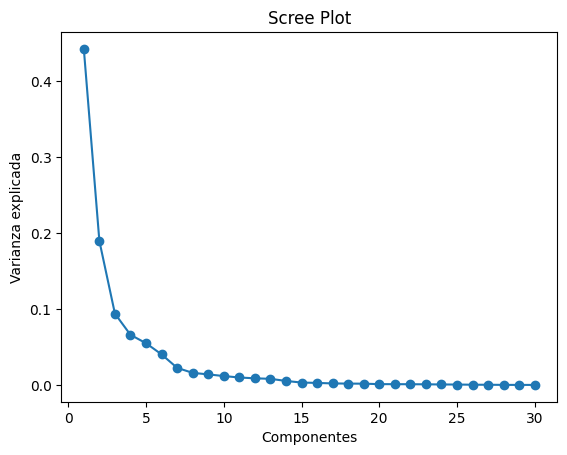

In [30]:
# método visual (método del codo para reducción de dimensionales)
import matplotlib.pyplot as plt

plt.plot(range(1,len(varianza)+1), varianza, marker='o')
plt.xlabel("Componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot")
plt.show()

# Reducción de dimensionalidad con T-SNE


In [ ]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=3)
tsne_components_3d=tsne.fit_transform(X_scaled)
tsne_components_3d[:1] #mostrar la primera fila de componentes


array([[11.476385  ,  0.55021936,  0.40580797]], dtype=float32)

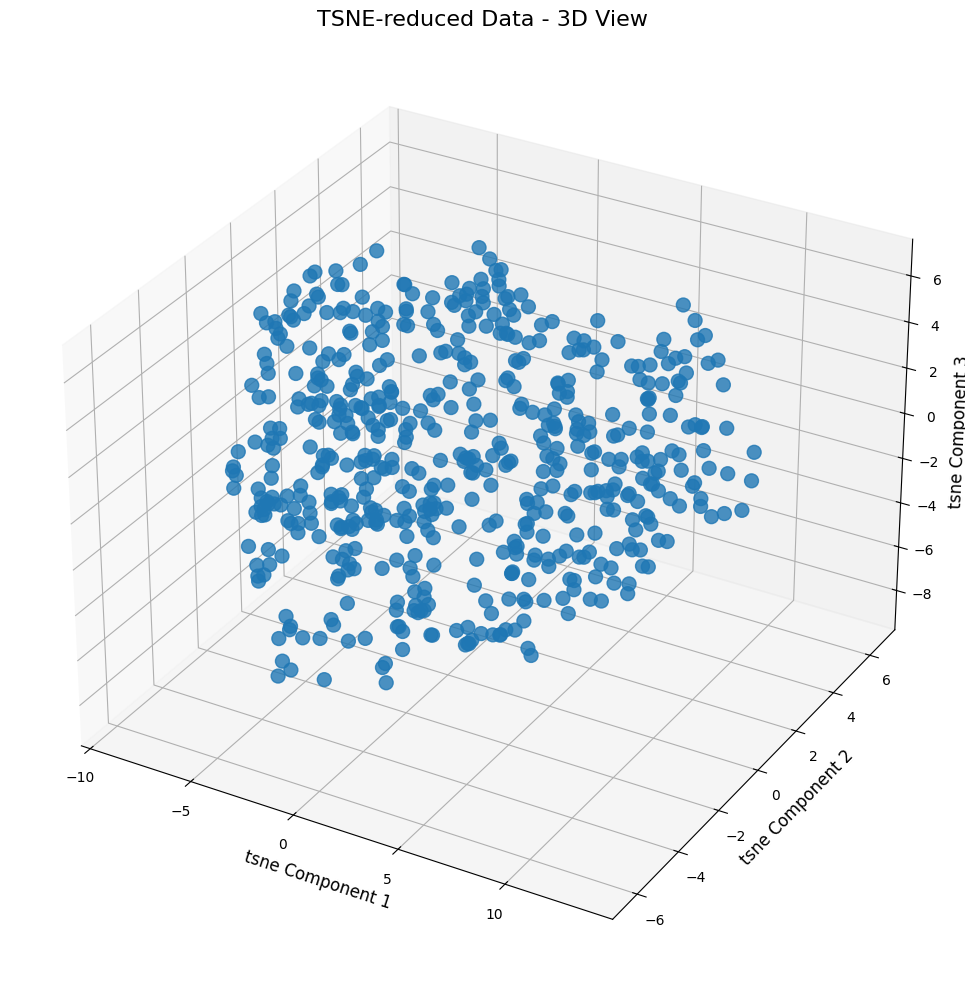

In [32]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

tsne_df_3d = pd.DataFrame(data=tsne_components_3d, columns=['tsne Component 1', 'tsne Component 2', 'tsne Component 3'])


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
        tsne_df_3d['tsne Component 1'],
        tsne_df_3d['tsne Component 2'],
        tsne_df_3d['tsne Component 3'],
        s=100,
        alpha=0.8
    )
ax.set_title('TSNE-reduced Data - 3D View', fontsize=16)
ax.set_xlabel('tsne Component 1', fontsize=12)
ax.set_ylabel('tsne Component 2', fontsize=12)
ax.set_zlabel('tsne Component 3', fontsize=12)
plt.tight_layout()
plt.show()

perplexity= número efectivo de vecinos considerados
1. Regla General de perplexity <n/3. n tamaño del dataset n=569 en este ejemplo

| n observaciones | perplexity recomendada |
| --------------- | ---------------------- |
| 50              | 5 – 15                 |
| 200             | 5 – 30                 |
| 1000            | 10 – 50                |
| >5000           | 30 – 100               |

2. Interpretación intuitiva
- perplexity baja (detecte micro-cluster, sensible al ruido)
- perplexity alto (detecte estructura global, puede mezclar clusters)

3. Método práctico. probar distintos valores de perplexity y comparar visualmente. (separa mejor los cluster, mantiene estructuras interpretables y evita ruido excesivo)

4. Heurística basado en tamaño del dataset. perplexity=sqrt(n)
| n   | √n | perplexity sugerida |
| --- | -- | ------------------- |
| 100 | 10 | 10                  |
| 400 | 20 | 20                  |
| 900 | 30 | 30                  |

In [33]:
np.sqrt(569)

np.float64(23.853720883753127)

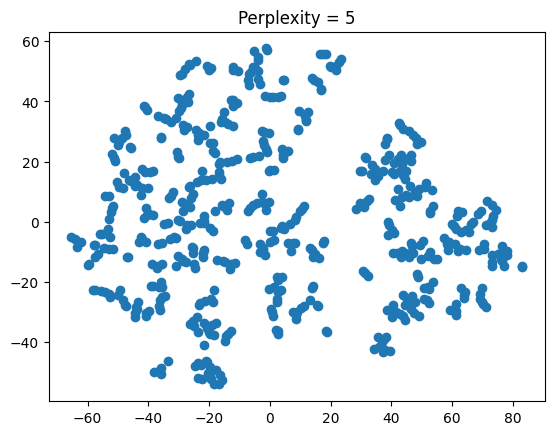

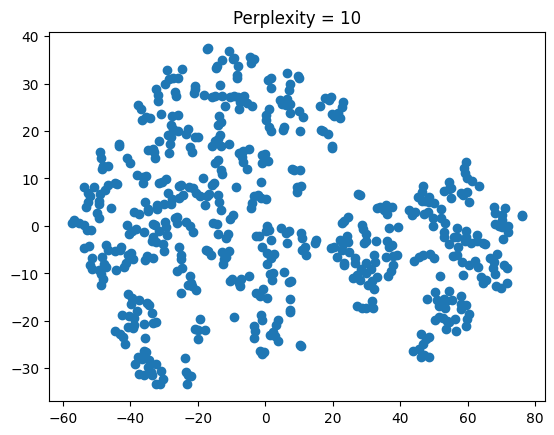

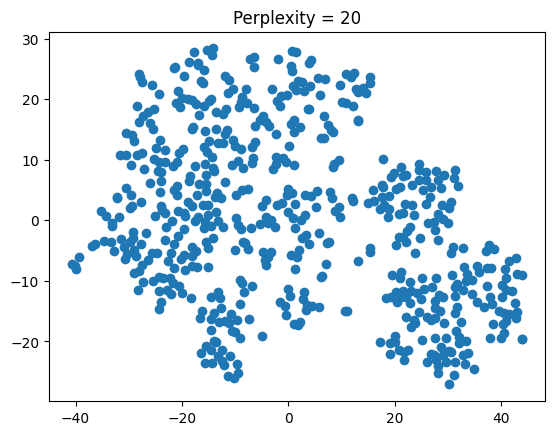

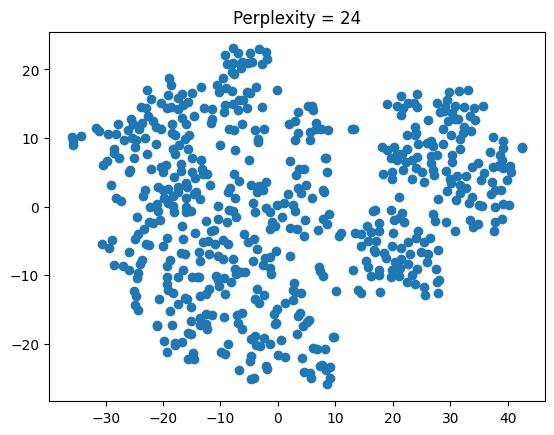

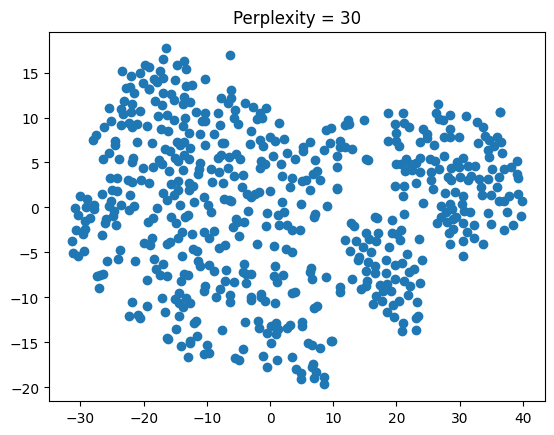

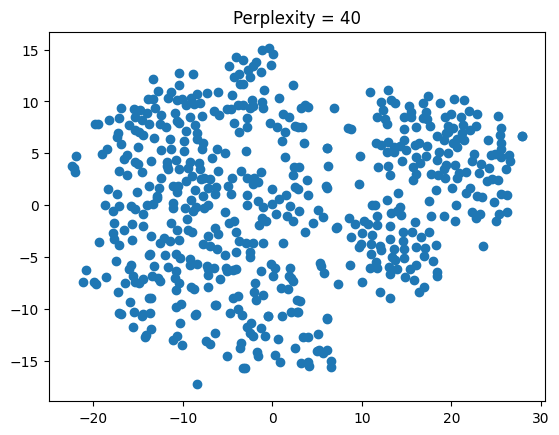

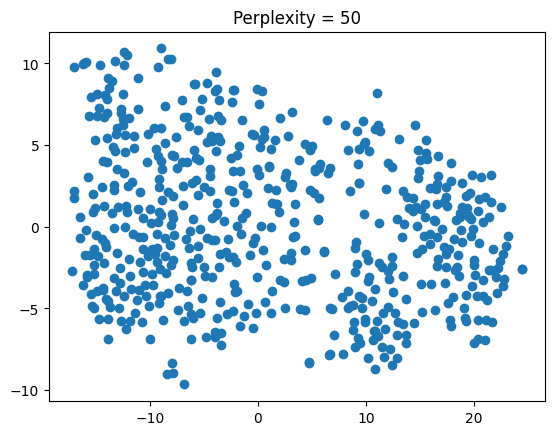

In [34]:
perplexities = [5,10,20,24,30,40,50]

for p in perplexities:
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.scatter(X_tsne[:,0], X_tsne[:,1])
    plt.title(f"Perplexity = {p}")
    plt.show()

- learning_rate = n/12 (tasa de aprendizaje)
- max_iter = 1000 - 2000 (minimo aceptable 250 en caso de tener demasiados datos)

In [35]:
#Ejemplo modificando hiperparámetros de TSNE
from sklearn.manifold import TSNE
tsne=TSNE(n_components=3,perplexity=50.0,max_iter=1000,learning_rate=47.4)
tsne_components_3d=tsne.fit_transform(X_scaled)
tsne_components_3d[:1]

array([[ 8.058681, -1.408039, -2.042512]], dtype=float32)

In [36]:
tsne.learning_rate_

47.4

In [37]:
tsne.n_iter_

999

In [38]:
tsne.kl_divergence_ # que tan diferente es la estructura en el espacio original respecto al reducido (mientras menor sea el valor → mejor preservación)

0.5936025381088257

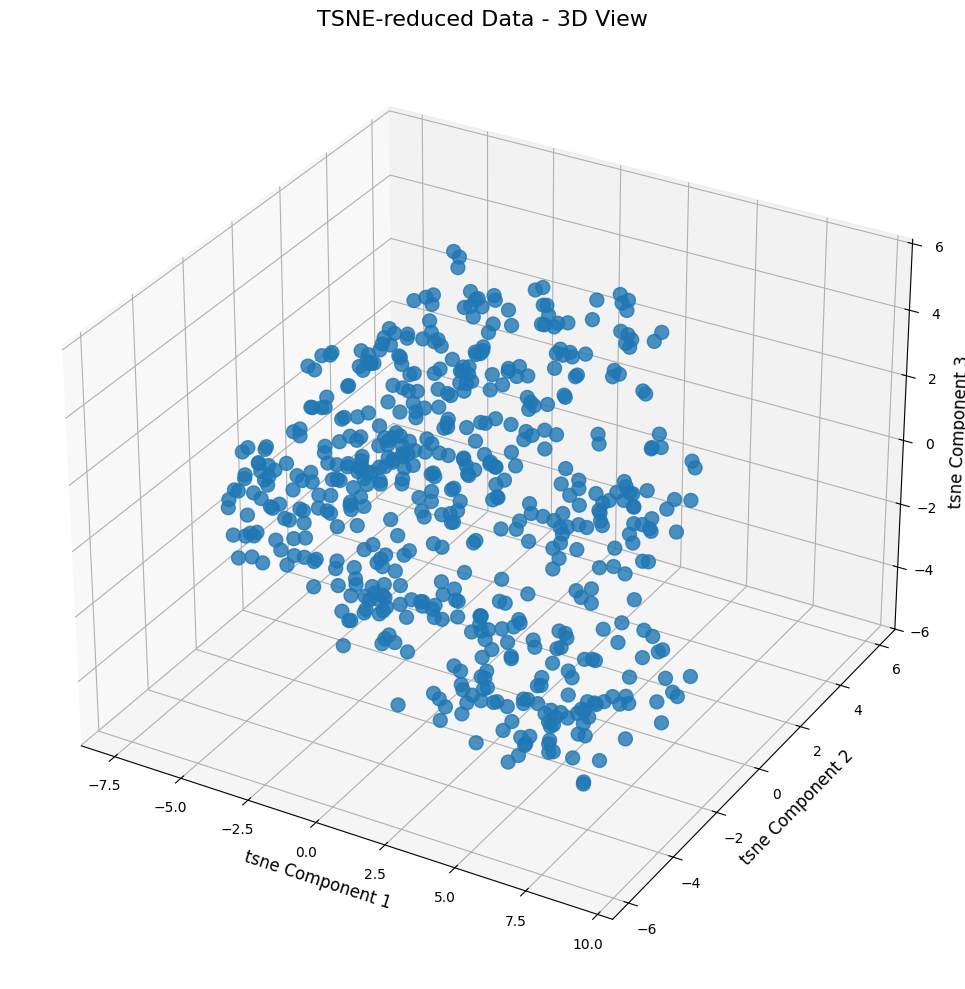

In [39]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

tsne_df_3d = pd.DataFrame(data=tsne_components_3d, columns=['tsne Component 1', 'tsne Component 2', 'tsne Component 3'])


fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
        tsne_df_3d['tsne Component 1'],
        tsne_df_3d['tsne Component 2'],
        tsne_df_3d['tsne Component 3'],
        s=100,
        alpha=0.8
    )
ax.set_title('TSNE-reduced Data - 3D View', fontsize=16)
ax.set_xlabel('tsne Component 1', fontsize=12)
ax.set_ylabel('tsne Component 2', fontsize=12)
ax.set_zlabel('tsne Component 3', fontsize=12)
plt.tight_layout()
plt.show()

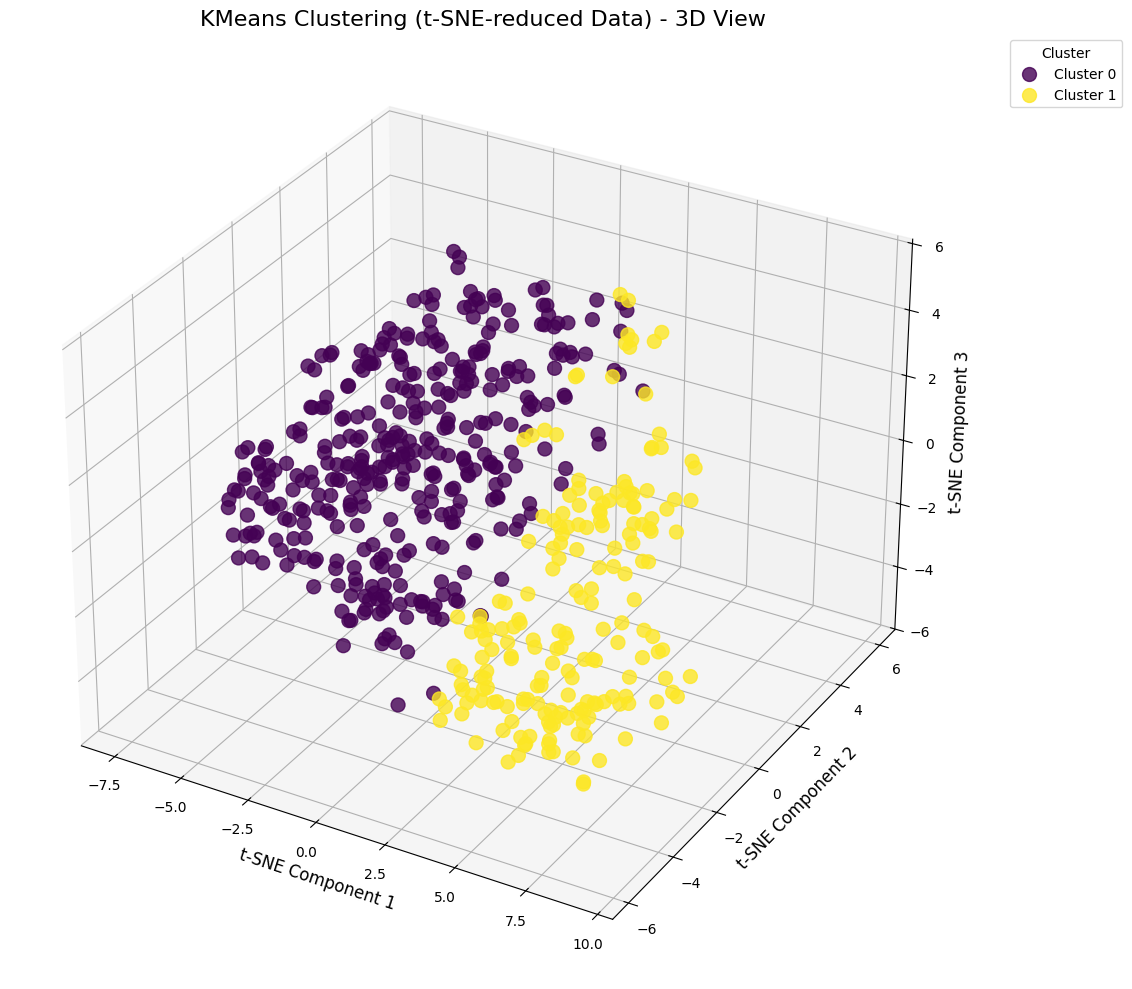

In [40]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

tsne_df_3d = pd.DataFrame(data=tsne_components_3d, columns=['t-SNE Component 1', 't-SNE Component 2', 't-SNE Component 3'])
tsne_df_3d['Cluster'] = X['Cluster']
# Define a colormap for consistent coloring
cmap = plt.get_cmap('viridis', len(tsne_df_3d['Cluster'].unique()))

for cluster in sorted(tsne_df_3d['Cluster'].unique()):
    cluster_data = tsne_df_3d[tsne_df_3d['Cluster'] == cluster]
    ax.scatter(
        cluster_data['t-SNE Component 1'],
        cluster_data['t-SNE Component 2'],
        cluster_data['t-SNE Component 3'],
        label=f'Cluster {cluster}',
        color=cmap(cluster),
        s=100,
        alpha=0.8
    )

ax.set_title('KMeans Clustering (t-SNE-reduced Data) - 3D View', fontsize=16)
ax.set_xlabel('t-SNE Component 1', fontsize=12)
ax.set_ylabel('t-SNE Component 2', fontsize=12)
ax.set_zlabel('t-SNE Component 3', fontsize=12)
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [41]:
#reducir ruido y acelerar TSNE - modelo híbrido
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=30)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=2000
)

X_tsne = tsne.fit_transform(X_pca)

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'